<a href="https://colab.research.google.com/github/zeinabkaraki419-jpg/rdkit-learning/blob/main/07_Day_Pandas/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 43.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd


generate DataFrame from dictionary

In [5]:
import pandas as pd

data = {
    'name': ['aspirin', 'paracetamol', 'ibuprofen', 'ethanol'],
    'smiles': ['CC(=O)Oc1ccccc1C(=O)O', 'CC(=O)Nc1ccc(O)cc1',
               'CC(C)Cc1ccc(cc1)C(C)C(=O)O', 'CCO']
}

df = pd.DataFrame(data)
print(df)

          name                      smiles
0      aspirin       CC(=O)Oc1ccccc1C(=O)O
1  paracetamol          CC(=O)Nc1ccc(O)cc1
2    ibuprofen  CC(C)Cc1ccc(cc1)C(C)C(=O)O
3      ethanol                         CCO


Add New Column MW

In [6]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def get_mw(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol)

df['MW'] = df['smiles'].apply(get_mw)
print(df)

          name                      smiles       MW
0      aspirin       CC(=O)Oc1ccccc1C(=O)O  180.159
1  paracetamol          CC(=O)Nc1ccc(O)cc1  151.165
2    ibuprofen  CC(C)Cc1ccc(cc1)C(C)C(=O)O  206.285
3      ethanol                         CCO   46.069


The .apply() method in Pandas works like a for loop applied to every row of a column. It takes a function and runs it automatically on each item, returning a new column with the calculated results.

Filtering

In [9]:

filtered_df = df[df['MW'] < 150]
print(filtered_df)

      name smiles      MW
3  ethanol    CCO  46.069


Sorting

In [8]:
df_sorted = df.sort_values('MW')          # Increasing order
df_sorted = df.sort_values('MW', ascending=False)  # Decreasing order
print(df_sorted)

          name                      smiles       MW
2    ibuprofen  CC(C)Cc1ccc(cc1)C(C)C(=O)O  206.285
0      aspirin       CC(=O)Oc1ccccc1C(=O)O  180.159
1  paracetamol          CC(=O)Nc1ccc(O)cc1  151.165
3      ethanol                         CCO   46.069


,Name,SMILES,ROMol
0,Ethanol,CCO,
1,Aspirin,CC(=O)Oc1ccccc1C(=O)O,
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O,
3,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,

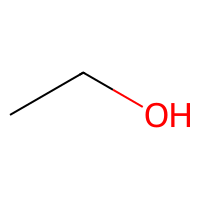
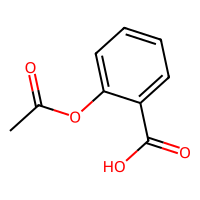
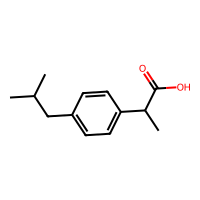
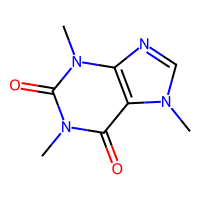

In [10]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors
# 1. Create a sample dataset with SMILES
data = {
    'Name': ['Ethanol', 'Aspirin', 'Ibuprofen', 'Caffeine'],
    'SMILES': ['CCO', 'CC(=O)Oc1ccccc1C(=O)O', 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O', 'Cn1cnc2c1c(=O)n(C)c(=O)n2C']
}
df = pd.DataFrame(data)
# 2. Add a Molecule Column from SMILES
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='SMILES', molCol='ROMol')
# 3. Enable 2D structure rendering in the DataFrame
PandasTools.ChangeMoleculeRendering(df)
# Display DataFrame
df

Calculating Descriptors Across Columns

In [11]:
# Calculate Molecular Weight and LogP for each molecule
df['MW'] = df['ROMol'].apply(Descriptors.MolWt)
df['LogP'] = df['ROMol'].apply(Descriptors.MolLogP)
df['Rotatable_Bonds'] = df['ROMol'].apply(Descriptors.NumRotatableBonds)
# View updated DataFrame
df[['Name', 'MW', 'LogP', 'Rotatable_Bonds']]

,Name,MW,LogP,Rotatable_Bonds
0,Ethanol,46.069,-0.0014,0
1,Aspirin,180.159,1.3101,2
2,Ibuprofen,206.285,3.0732,4
3,Caffeine,194.194,-1.0293,0


In medicinal chemistry, a Rotatable Bond is any single non-ring bond attached to a non-hydrogen heavy atom that can rotate freely 360 degree without breaking.

 Substructure Filtering on DataFrames

In [12]:
# Define a SMARTS query (e.g., Aromatic Ring)
aromatic_pattern = Chem.MolFromSmarts('a1aaaaa1')
# Filter DataFrame to keep only molecules containing an aromatic ring
aromatic_df = df[df['ROMol'].apply(lambda mol: mol.HasSubstructMatch(aromatic_pattern))]
aromatic_df[['Name', 'SMILES']]

,Name,SMILES
1,Aspirin,CC(=O)Oc1ccccc1C(=O)O
2,Ibuprofen,CC(C)CC1=CC=C(C=C1)C(C)C(=O)O
3,Caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C
